# Final Results, Football Transfer Outcome Prediction

## Problem Overview
- What question are we solving?
    - We aim to predict whether a football player’s performance will decline after being transferred to a new team. The model classifies players as either likely to maintain/improve performance or likely to decline, based on pre-transfer statistics, market values, and positional and league information.

- Why matters? is it important?
    - Player transfers involve millions in investment and strategic planning. Many signings underperform post-transfer, leading to financial losses and poor team performance. By forecasting decline risk, clubs can make data-driven recruitment decisions, reduce scouting uncertainty, and improve overall return on investment in player acquisitions.

- Key metric(s):

    - Accuracy: 0.72 — overall predictive performance.
    - ROC-AUC: 0.76 — measures the model’s ability to distinguish declining vs. non-declining players.
    - F1-Score (Decline class): 0.59 — balances precision and recall for identifying underperforming transfers.

## Load Processed Data

In [3]:
import pandas as pd

df = pd.read_csv("../data/processed/merged_clean_refined.csv")
print(df.shape)
df.head()

(4829, 20)


,from_league,to_league,Position,sub_position,position,foot,GA90_pre,GA_pre,PreMinutes,transfer_fee,market_value_in_eur,market_value_in_eur_player,highest_market_value_in_eur,country_of_birth,country_of_citizenship,height_in_cm,transfer_date,date_of_birth,contract_expiration_date,DeclineFlag
0,GR1,TR1,Midfielder,Central Midfield,Midfield,left,0.091993,3.0,2935.0,0.0,2000000.0,1500000.0,14000000.0,Netherlands,Netherlands,175.0,2025-02-07,1995-01-03 00:00:00,2025-06-30 00:00:00,0.0
1,GB1,NL1,FullBack,Left-Back,Defender,left,0.000000,0.0,1276.0,0.0,15000000.0,12000000.0,22000000.0,Netherlands,Netherlands,169.0,2025-02-04,1999-08-17 00:00:00,2025-06-30 00:00:00,1.0
2,IT1,IT1,FullBack,Left-Back,Defender,left,0.288462,15.0,4680.0,0.0,2000000.0,2000000.0,12000000.0,Italy,Italy,185.0,2025-02-03,1992-09-01 00:00:00,2025-06-30 00:00:00,1.0
3,ES1,ES1,FullBack,Left-Back,Defender,left,0.275229,4.0,1308.0,0.0,2500000.0,2500000.0,20000000.0,Spain,Spain,170.0,2025-02-03,1993-03-01 00:00:00,2025-06-30 00:00:00,1.0
4,GB1,SC1,Midfielder,Left Midfield,Midfield,left,0.284710,9.0,2845.0,0.0,6000000.0,5000000.0,12000000.0,Germany,Ghana,178.0,2025-02-03,1992-12-23 00:00:00,2025-05-31 00:00:00,1.0


In [6]:
df.columns

Index(['from_league', 'to_league', 'Position', 'sub_position', 'position',
       'foot', 'GA90_pre', 'GA_pre', 'PreMinutes', 'transfer_fee',
       'market_value_in_eur', 'market_value_in_eur_player',
       'highest_market_value_in_eur', 'country_of_birth',
       'country_of_citizenship', 'height_in_cm', 'transfer_date',
       'date_of_birth', 'contract_expiration_date', 'DeclineFlag'],
      dtype='object')

## Train the Final Model

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, roc_auc_score
import pandas as pd
import joblib
import os

# Ensure artifact directory exists
os.makedirs("../artifacts", exist_ok=True)

# Define features and target
X = df.drop(columns=['DeclineFlag'])
y = df['DeclineFlag']

# Identify categorical and numeric columns
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numeric_cols = X.select_dtypes(exclude=['object']).columns.tolist()

# Preprocessing: impute missing values + encode categorical variables
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Define model
rf_clf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    random_state=42,
    class_weight='balanced'
)

# Combine preprocessing + model into a pipeline
final_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", rf_clf)
])

# Train model
final_model.fit(X_train, y_train)

# Evaluate briefly
y_pred = final_model.predict(X_test)
y_prob = final_model.predict_proba(X_test)[:, 1]
print(classification_report(y_test, y_pred))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.3f}")

# Save model
joblib.dump(final_model, "../artifacts/final_model.pkl")
print("Final model trained and saved to ../artifacts/final_model.pkl")

              precision    recall  f1-score   support

         0.0       0.73      0.85      0.78       588
         1.0       0.68      0.51      0.59       378

    accuracy                           0.72       966
   macro avg       0.71      0.68      0.68       966
weighted avg       0.71      0.72      0.71       966

ROC-AUC: 0.764
Final model trained and saved to ../artifacts/final_model.pkl


## ROC Curve

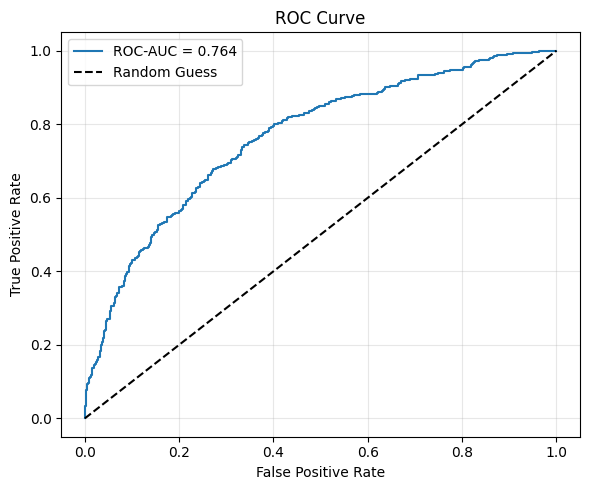

In [10]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

y_prob = final_model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc_score(y_test, y_prob):.3f}")
plt.plot([0,1],[0,1],'k--',label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../results/final/roc_curve.png")
plt.show()


## Model Evaluation and Visualization

Classification Report:

              precision    recall  f1-score   support

         0.0       0.73      0.85      0.78       588
         1.0       0.68      0.51      0.59       378

    accuracy                           0.72       966
   macro avg       0.71      0.68      0.68       966
weighted avg       0.71      0.72      0.71       966

Accuracy: 0.715
ROC-AUC: 0.764
✅ Metrics saved to ../results/final/kpi_metrics.json


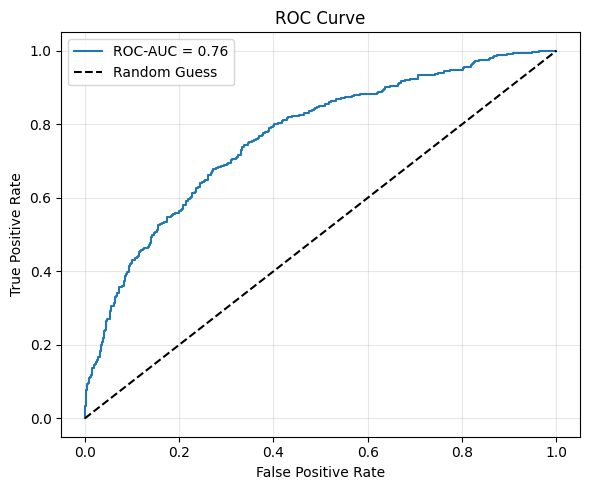

✅ ROC curve saved to ../results/final/roc_curve.png


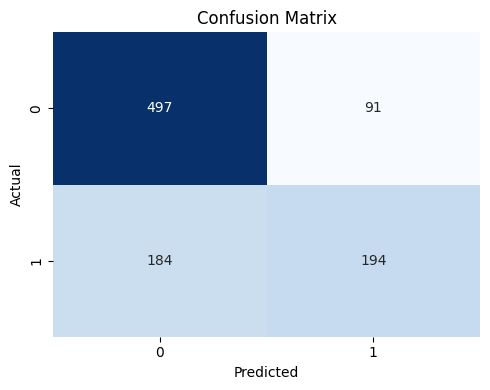

✅ Confusion matrix saved to ../results/final/confusion_matrix.png
✅ Test predictions saved to ../results/final/test_predictions.csv


In [ ]:
from sklearn.metrics import (
    accuracy_score, roc_auc_score, confusion_matrix, roc_curve, classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import json
import os

# Ensure results directory exists
os.makedirs("../results/final", exist_ok=True)

# --- Evaluate on Test Data ---
y_pred = final_model.predict(X_test)
y_prob = final_model.predict_proba(X_test)[:, 1]

# Compute Metrics
acc = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)
print("Classification Report:\n")
print(classification_report(y_test, y_pred))
print(f"Accuracy: {acc:.3f}")
print(f"ROC-AUC: {roc_auc:.3f}")

# Save KPI metrics
metrics = {"accuracy": acc, "roc_auc": roc_auc}
with open("../results/final/kpi_metrics.json", "w") as f:
    json.dump(metrics, f, indent=4)
print("Metrics saved to ../results/final/kpi_metrics.json")

# --- ROC Curve ---
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], 'k--', label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../results/final/roc_curve.png")
plt.show()
print(" ROC curve saved to ../results/final/roc_curve.png")

# --- Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("../results/final/confusion_matrix.png")
plt.show()
print(" Confusion matrix saved to ../results/final/confusion_matrix.png")

# --- Save Predictions (optional) ---
pred_df = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred,
    "Predicted_Prob": y_prob
})
pred_df.to_csv("../results/final/test_predictions.csv", index=False)
print(" Test predictions saved to ../results/final/test_predictions.csv")
